# Cu Nanoparticles in situ formation in LDPE

## Set_up()

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

✓ Workspace ready


# Data

In [2]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872\MASK_SAXS_1p4m_12keV.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

##### Cu 0.5%

In [3]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)

##### Cu 3%

In [4]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

In [5]:
Time_3_iso = Cu_3_iso.get_Time_profile()
Temp_3_iso = Cu_3_iso.get_T_profile()
Time_3_heat = Cu_3_heat.get_Time_profile()
Temp_3_heat = Cu_3_heat.get_T_profile()

Found 60 EDF files in SAXS
Found 89 EDF files in SAXS


In [6]:
Time_05_iso = Cu_05_iso.get_Time_profile()
Temp_05_iso = Cu_05_iso.get_T_profile()
Time_05_heat = Cu_05_heat.get_Time_profile()
Temp_05_heat = Cu_05_heat.get_T_profile()

Found 66 EDF files in SAXS
Found 88 EDF files in SAXS


# Functions

In [7]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>3)*(q<3.3)])
    #return q, I

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

def Invariant(q, I):
    l = 0.15
    r = 1.5
    x = q[(q>l)*(q<r)]
    y = I[(q>l)*(q<r)]
    return np.trapezoid(y*x**2, x=x)

import scipy
def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global sigma
    sigma = p*Ravg
    ro = scale
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(((4*np.pi / 3)**2) * (ro**2) * scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    #f = np.array(f)
    return Iq

def linear(x, a, b):
    return a * x + b

# Analysis

##### style

In [6]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

### SAXS

In [21]:
q_SAXS, I_SAXS_3_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_3_heat)

q_SAXS, I_SAXS_3_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_3_iso)

In [22]:
q_SAXS, I_SAXS_05_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_05_heat)

q_SAXS, I_SAXS_05_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q_SAXS, I_SAXS_05_iso)

##### Guinier

In [219]:
linear


<function __main__.linear(x, a, b)>

C:\Users\LabPC\AppData\Local\Temp\ipykernel_13180\3493402393.py:2: RuntimeWarning:

invalid value encountered in log



R_g =  11.16605278117659
q * R_g 1.8995658436011886
R_g =  2.4430723663194533
q * R_g 2.8201923194007628


(-1.0, 8.0)

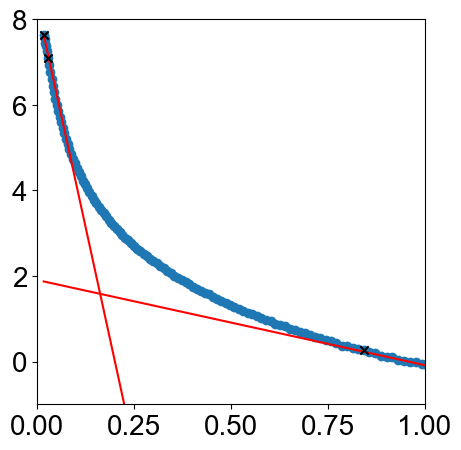

In [239]:
plt.figure(figsize=(5,5))
Y = np.log(I_SAXS_05_iso[-1] - I_SAXS_05_heat[45])
X = q_SAXS ** 2

plt.scatter(X, Y)

left = 0
right = 5

plt.scatter([X[left], X[right]], [Y[left], Y[right]], marker='x', zorder=10, color='black')
p, cov = curve_fit(linear, X[left:right], Y[left:right])

plt.plot(X, linear(X, *p), color='red')
R_g = np.sqrt(-p[0] * 3)
print('R_g = ', R_g)
print('q * R_g', np.sqrt(X[right]) * R_g)

left = 100
right = 130


plt.scatter([X[left], X[right]], [Y[left], Y[right]], marker='x', zorder=10, color='black')
p, cov = curve_fit(linear, X[left:right], Y[left:right])

plt.plot(X, linear(X, *p), color='red')
R_g = np.sqrt(-p[0] * 3)
print('R_g = ', R_g)
print('q * R_g', np.sqrt(X[right]) * R_g)

plt.xlim(0, 1)
plt.ylim(-1, 8)

[]

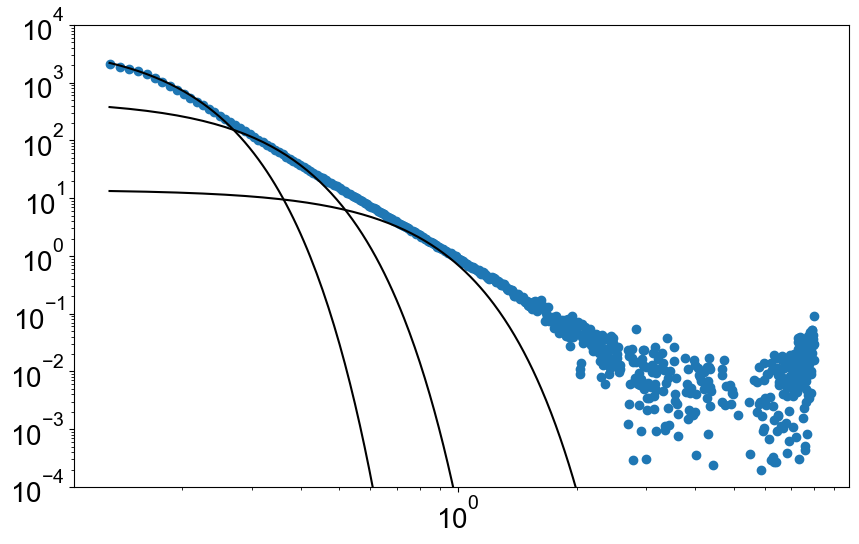

In [200]:

plt.scatter(q_SAXS,  I_SAXS_05_iso[-1] - I_SAXS_05_heat[45])

plt.plot(q_SAXS, Guinier(q_SAXS, 5e3, 12), zorder=10, color='black')
plt.plot(q_SAXS, Guinier(q_SAXS, 5e2, 7), zorder=10, color='black')
plt.plot(q_SAXS, Guinier(q_SAXS, 1.4e1, 3), zorder=10, color='black')

plt.ylim(1e-4, 1e4)
plt.semilogx()
plt.semilogy()

##### Invariant

In [32]:
Invariant_3 = []

for i in range(89):
    Invariant_3.append(Invariant(q_SAXS, I_SAXS_3_heat[i]))

for i in range(60):
    Invariant_3.append(Invariant(q_SAXS, I_SAXS_3_iso[i]))

Invariant_05 = []

for i in range(88):
    Invariant_05.append(Invariant(q_SAXS, I_SAXS_05_heat[i]))

for i in range(66):
    Invariant_05.append(Invariant(q_SAXS, I_SAXS_05_iso[i])) 

Invariant_05 -= min(Invariant_05)
Invariant_3 -= min(Invariant_3)

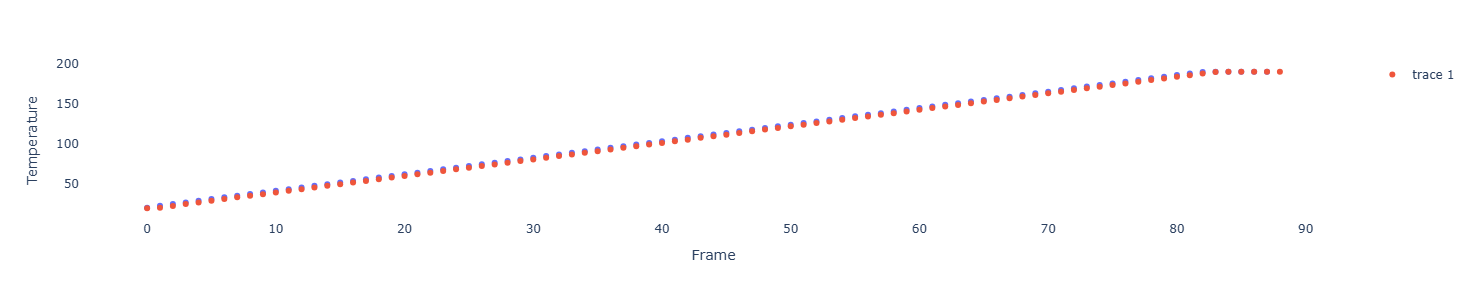

In [86]:
import plotly.express as px

fig = px.scatter(x=list(range(len(Temp_05_heat))), y=Temp_05_heat)
fig.add_scatter(x=list(range(len(Temp_3_heat))), y=Temp_3_heat, mode='markers')
fig.update_layout(
    width=500, 
    height=300,
    xaxis_title='Frame',
    yaxis_title='Temperature',
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()

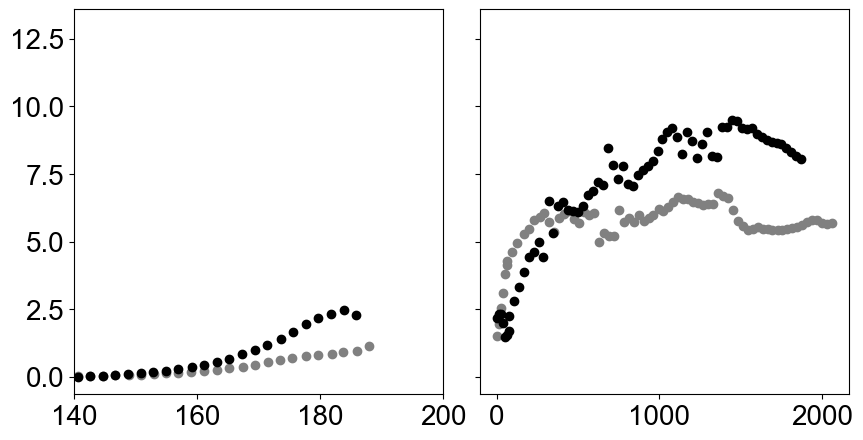

In [134]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax1.scatter(Temp_05_heat[:82], Invariant_05[:82], color='grey')
ax2.scatter(Time_05_heat[82:] - Time_05_heat[82], Invariant_05[82:88], color='grey')
ax2.scatter(Time_05_iso + Time_05_heat[87] - Time_05_heat[82], Invariant_05[88:], color='grey')

ax1.scatter(Temp_3_heat[:82], Invariant_3[:82], color='black')
ax2.scatter(Time_3_heat[82:] - Time_3_heat[82], Invariant_3[82:89], color='black')
ax2.scatter(Time_3_iso + Time_3_heat[88] - Time_3_heat[82], Invariant_3[89:], color='black')

ax1.set_xlim(140, 200)
plt.subplots_adjust(wspace=0.1)  # уменьшаем расстояние между графиками

### WAXS

In [97]:
q_WAXS, I_WAXS_3_heat = Cu_3_heat.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_3_heat)

q_WAXS, I_WAXS_3_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_3_iso)

In [123]:
q_WAXS, I_WAXS_05_heat = Cu_05_heat.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_05_heat)

q_WAXS, I_WAXS_05_iso = Cu_05_iso.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q_WAXS, I_WAXS_05_iso)

In [124]:
I_111_3 = []

for i in range(89):
    I_111_3.append(I_WAXS_3_heat[i][553])

for i in range(60):
    I_111_3.append(I_WAXS_3_iso[i][553])    

I_111_05 = []

for i in range(88):
    I_111_05.append(I_WAXS_05_heat[i][552])

for i in range(66):
    I_111_05.append(I_WAXS_05_iso[i][552])    

# Figures

### Fig 1a

In [283]:
Temp_3_heat[84]

np.int64(25)

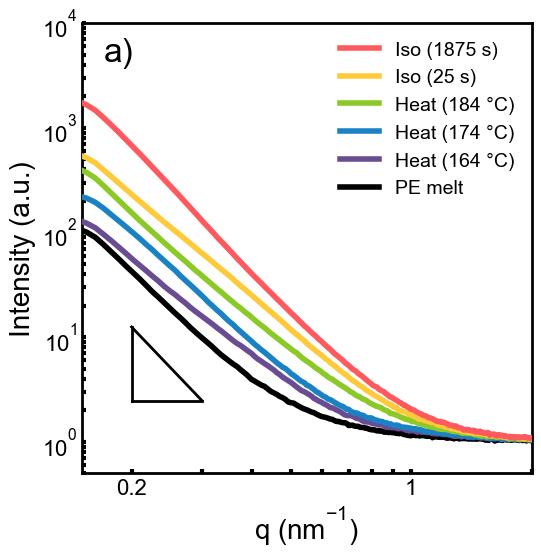

In [284]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 0

q = q_SAXS
I1 = I_SAXS_05_iso
I2 = I_SAXS_05_heat

ax.plot(q, I1[59] -  K * I2[45], linewidth=4, label='Iso (1875 s)', color='#ff595e', zorder=10)
ax.plot(q, I2[84] -  K * I2[45], linewidth=4, label='Iso (25 s)', color='#ffca3a', zorder=9)

ax.plot(q, I2[82] - K * I2[45], linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, I2[75] - K * I2[45], linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, I2[70] - K * I2[45], linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=6)

ax.plot(q, I2[45] - K * I2[45] , linewidth=4, label='PE melt', color='black', zorder=1)


lnsp = np.linspace(0.2, 0.3, 1000)
plt.plot(lnsp, lnsp**-4 / 50, color='black', linewidth=2)
plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 50), color='black', linewidth=2)
plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 50, color='black',linewidth=2)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.15, 2)
ax.set_ylim(0.5, 1e4)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'a)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\Nps Cu\Figures\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)


### Fig 1b

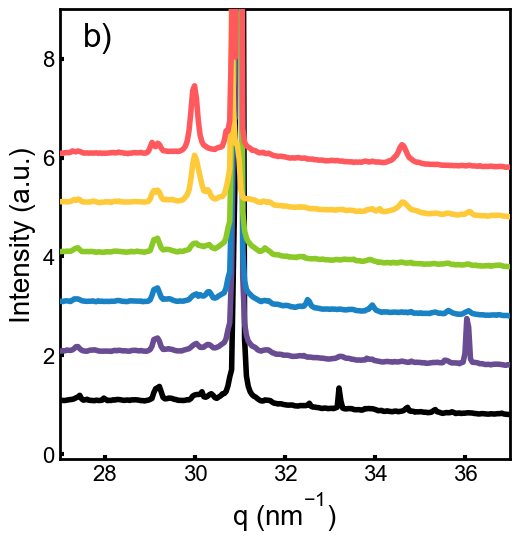

In [278]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 1

q = q_WAXS
I1 = I_WAXS_05_iso
I2 = I_WAXS_05_heat

ax.plot(q, I1[59]  + 5 * K, linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)
p = 553
#plt.scatter(q[p], I_3_iso[59][p] + 5 * K, marker = 'x', s=200, color='black', zorder=100)

ax.plot(q, I1[5]  + 4 * K, linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, I2[80]  + 3 * K, linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, I2[75] + 2 * K, linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, I2[70] + K, linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=5)

ax.plot(q, I2[50] , linewidth=4, label='PE melt', color='black', zorder=1)


lnsp = np.linspace(0.2, 0.3, 1000)
plt.plot(lnsp, lnsp**-4 / 10, color='black', linewidth=2)
plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 10), color='black', linewidth=2)
plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 10, color='black',linewidth=2)

ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(27, 37)
ax.set_ylim(-0.1, 9)
ax.set_yticks([0, 2, 4, 6, 8])
#ax.set_xticklabels(['0.2', '1'])

# Легенда
#ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'b)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left', zorder=100)

ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((-2, 3)) 
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.savefig(r'E:\Nps Cu\Figures\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)

### Fig 1c

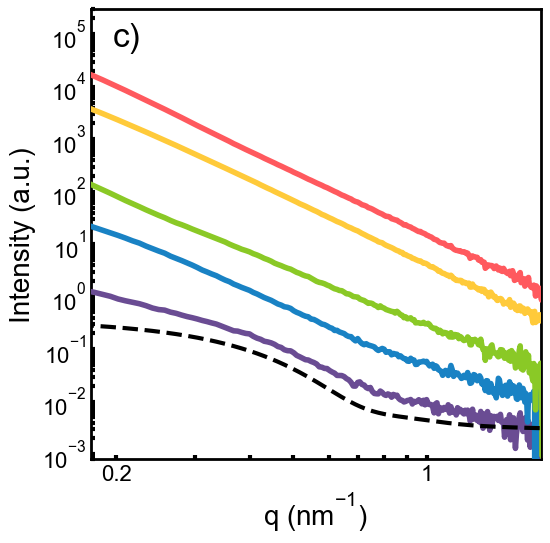

In [280]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 0.98

q = q_SAXS
I1 = I_SAXS_05_iso
I2 = I_SAXS_05_heat

ax.plot(q, (I1[59] -  K * I2[45]) * 16, linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)

ax.plot(q, (I1[5] -  K * I2[45]) * 4, linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, (I2[80] - K * I2[45]), linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, (I2[75] - K * I2[45]) / 4, linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, (I2[70] - K * I2[45]) / 16, linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=5)

ax.plot(q, 0.01*np.array(Polydisperse_spheres(q, 0.8e-2, 5, 0.25, 3e-1)), color='black', label='Form-factor', linewidth=3, linestyle='--', zorder=30)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.175, 1.8)
ax.set_ylim(0.8e-3, 3e5)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
# ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'c)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left', zorder=30)

ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.savefig(r'E:\Nps Cu\Figures\Fig1_c.png', dpi=300, bbox_inches='tight', transparent=True)

### Fig 2

In [ ]:
Time_3_iso + Time_3_heat[88] - Time_3_heat[82]

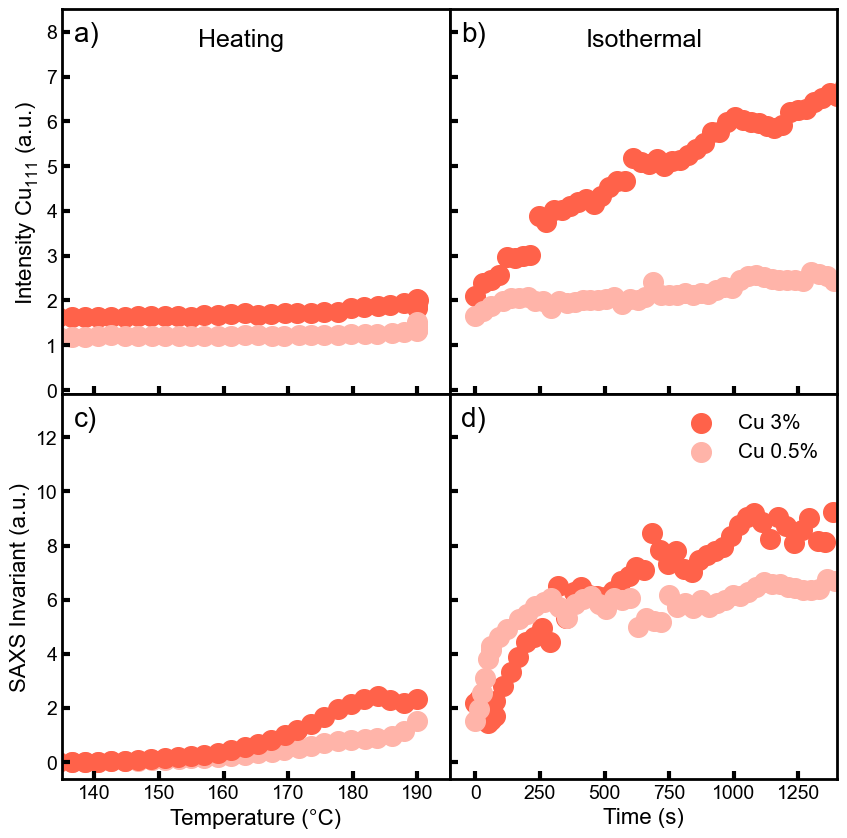

In [150]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), 
                        sharex='col',  # общие оси X в столбцах
                        sharey='row',  # общие оси Y в строках
                        gridspec_kw={'hspace': 0.00, 'wspace': 0.00})

# Извлекаем оси для удобства
(ax1, ax2), (ax3, ax4) = axs

K = 150
s = 200

# --- ВЕРХНИЙ РЯД: Интенсивность Cu111 --
Color_3 = '#FF624A'
Color_05 = '#FFB4A9'

# График нагрева (левая верхняя панель)
ax1.scatter(Temp_3_heat, I_111_3[:89], s=s, color=Color_3, zorder=0)
ax1.scatter(Temp_05_heat, I_111_05[:88], s=s, color=Color_05, zorder=0)
ax1.text(0.35, 0.95, 'Heating', transform=ax1.transAxes, fontsize=18, 
         fontfamily='Arial', verticalalignment='top')
ax1.tick_params(labelbottom=False)  # скрываем подписи X для верхней строки

# График изотермы (правая верхняя панель)
ax2.scatter(Time_3_iso, I_111_3[89:], s=s, color=Color_3, zorder=0)
ax2.scatter(Time_05_iso, I_111_05[88:], s=s, color=Color_05, zorder=0)
ax2.text(0.35, 0.95, 'Isothermal', transform=ax2.transAxes, fontsize=18,
         fontfamily='Arial', verticalalignment='top')
ax2.tick_params(labelbottom=False, labelleft=False)  # скрываем подписи

# Общая ось Y для верхнего ряда
ax1.set_ylabel('Intensity Cu$_{111}$ (a.u.)', fontsize=16, fontfamily='Arial')
ax1.set_ylim(-0.1, 8.5)

# --- НИЖНИЙ РЯД: SAXS инвариант ---

# График нагрева (левая нижняя панель)
ax3.scatter(Temp_05_heat[:83], Invariant_05[:83], s=s, color=Color_05, zorder=0)
ax3.scatter(Temp_3_heat[:84], Invariant_3[:84], s=s, color=Color_3, zorder=0)
ax3.set_xlabel('Temperature (°C)', fontsize=16, fontfamily='Arial')
ax3.set_xlim(135, 195)

# График изотермы (правая нижняя панель)
ax4.scatter(Time_3_heat[82:] - Time_3_heat[82], Invariant_3[82:89], s=s, color=Color_3, zorder=0)
ax4.scatter(Time_3_iso + Time_3_heat[88] - Time_3_heat[82], Invariant_3[89:], s=s, color=Color_3, zorder=0)
ax4.scatter(Time_05_heat[82:] - Time_05_heat[82], Invariant_05[82:88], s=s, color=Color_05, zorder=0)
ax4.scatter(Time_05_iso + Time_05_heat[87] - Time_05_heat[82], Invariant_05[88:], s=s, color=Color_05, zorder=0)


ax4.set_xlabel('Time (s)', fontsize=16, fontfamily='Arial')
ax4.set_xlim(-100, 1400)
ax4.tick_params(labelleft=False)  # скрываем подписи Y справа

# Общая ось Y для нижнего ряда
ax3.set_ylabel('SAXS Invariant (a.u.)', fontsize=16, fontfamily='Arial')

# --- ОФОРМЛЕНИЕ ВСЕХ ГРАФИКОВ ---
for ax in [ax1, ax2, ax3, ax4]:
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.spines[axis].set_zorder(200)  
    ax.tick_params(axis="both", which='both', direction="in", width=3, length=6, labelsize=14, 
                   # top=True, bottom=True, left=True, right=True, 
                   zorder=201)
    
    # Шрифты для подписей
    for tick in ax.get_xticklabels():
        tick.set_fontfamily('Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontfamily('Arial')

# Добавляем легенду (например, в последней панели)
ax4.scatter([], [], s=s, color=Color_3, label='Cu 3%')
ax4.scatter([], [], s=s, color=Color_05, label='Cu 0.5%')
ax4.legend(fontsize=15, frameon=False, loc='upper right')

# Добавляем буквенные подписи
labels = ['a)', 'b)', 'c)', 'd)']
axes = [ax1, ax2, ax3, ax4]
for ax, label in zip(axes, labels):
    ax.text(0.03, 0.97, label, transform=ax.transAxes, fontsize=20, 
            fontfamily='Arial', verticalalignment='top')


plt.savefig(r'E:\Nps Cu\Figures\Fig2.png', dpi=300, bbox_inches='tight', transparent=True)